# Selección de Portafolios como Problema de Búsqueda

**Problema:** Distribuir un capital $C$ entre $n$ opciones de inversión, cada una con rendimiento esperado $r_i$.

| Componente | Descripción |
|---|---|
| **Espacio $\Omega$** | Símplex estándar: $\{\mathbf{x} \in \mathbb{R}^n \mid x_i \geq 0,\ \sum x_i = 1\}$ |
| **Configuración** | Vector $(x_1, x_2, \ldots, x_n)$ de fracciones de capital |
| **Tamaño** | Continuo: $\infty$. Discretizado con paso $\delta=1/k$: $\binom{k+n-1}{n-1}$ |
| **Función de costo** | Maximizar $f(\mathbf{x}) = \sum_i x_i r_i$ s.a. $\text{Var}(\mathbf{x}) \leq \sigma^2_{\max}$ |

In [2]:
# Instalación de dependencias (si es necesario)
# !pip install matplotlib networkx numpy scipy --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from itertools import product
from math import comb
from scipy.special import comb as comb_float

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Espacio de Configuraciones y su Tamaño

In [10]:
def tamanio_omega(n, k):
    """
    Calcula |Ω| = C(k+n-1, n-1)
    n: número de opciones de inversión
    k: número de partes iguales en que se divide el capital (1/k cada una)
    """
    return comb(k + n - 1, n - 1)

print('Tamaño del espacio de búsqueda |Ω| = C(k+n-1, n-1)\n')
print(f'{"n (opciones)":>14} | {"k=3 (δ=1/3)":>12} | {"k=5 (δ=1/5)":>12} | {"k=10 (δ=1/10)":>14}')
print('-' * 60)
for n in [2, 3, 4, 5, 10]:
    vals = [tamanio_omega(n, k) for k in [3, 5, 10]]
    print(f'{n:>14} | {vals[0]:>12,} | {vals[1]:>12,} | {vals[2]:>14,}')

Tamaño del espacio de búsqueda |Ω| = C(k+n-1, n-1)

  n (opciones) |  k=3 (δ=1/3) |  k=5 (δ=1/5) |  k=10 (δ=1/10)
------------------------------------------------------------
             2 |            4 |            6 |             11
             3 |           10 |           21 |             66
             4 |           20 |           56 |            286
             5 |           35 |          126 |          1,001
            10 |          220 |        2,002 |         92,378


## 2. Generación del Espacio de Configuraciones

In [11]:
def generar_configuraciones(n, k):
    """
    Genera todos los vectores (x_1,...,x_n) con x_i ∈ {0,1/k,...,1}
    y sum(x_i) = 1. Usa backtracking para eficiencia.
    """
    configs = []

    def backtrack(restante_k, actual, idx):
        if idx == n - 1:
            actual.append(restante_k / k)
            configs.append(tuple(actual))
            actual.pop()
            return
        for paso in range(restante_k + 1):
            actual.append(paso / k)
            backtrack(restante_k - paso, actual, idx + 1)
            actual.pop()

    backtrack(k, [], 0)
    return configs

# Ejemplo: n=3 opciones, k=3 (δ=1/3)
n, k = 3, 3
configs = generar_configuraciones(n, k)

print(f'n={n} opciones, δ=1/{k} → |Ω| = {len(configs)} configuraciones\n')
print('Todas las configuraciones (x₁, x₂, x₃):')
for i, c in enumerate(configs):
    fracs = [f'{int(x*k)}/{k}' if x not in (0.0, 1.0) else str(int(x)) for x in c]
    print(f'  {i+1:>2}. ({", ".join(fracs)})')

n=3 opciones, δ=1/3 → |Ω| = 10 configuraciones

Todas las configuraciones (x₁, x₂, x₃):
   1. (0, 0, 1)
   2. (0, 1/3, 2/3)
   3. (0, 2/3, 1/3)
   4. (0, 1, 0)
   5. (1/3, 0, 2/3)
   6. (1/3, 1/3, 1/3)
   7. (1/3, 2/3, 0)
   8. (2/3, 0, 1/3)
   9. (2/3, 1/3, 0)
  10. (1, 0, 0)


## 3. Función de Costo

In [5]:
def rendimiento_esperado(x, r):
    """f(x) = sum(x_i * r_i)"""
    return np.dot(x, r)

def varianza_portafolio(x, cov):
    """Var(x) = x^T Σ x"""
    return float(np.array(x) @ cov @ np.array(x))

# Rendimientos esperados para 3 opciones
r = np.array([0.05, 0.12, 0.20])   # 5%, 12%, 20%

# Matriz de covarianza (correlación entre activos)
cov = np.array([
    [0.01,  0.002, 0.004],
    [0.002, 0.04,  0.006],
    [0.004, 0.006, 0.09 ]
])

sigma_max = 0.12   # riesgo máximo permitido

# Evaluación de todas las configuraciones
resultados = []
for c in configs:
    f = rendimiento_esperado(c, r)
    var = varianza_portafolio(c, cov)
    factible = var <= sigma_max**2
    resultados.append({'config': c, 'rendimiento': f, 'varianza': var, 'factible': factible})

resultados.sort(key=lambda d: -d['rendimiento'])

print(f'Rendimientos r = {r}')
print(f'Riesgo máximo σ_max = {sigma_max}\n')
print(f'{"Config":>20} | {"f(x)":>8} | {"Var(x)":>8} | {"Factible":>9}')
print('-' * 55)
for d in resultados:
    c = d['config']
    fracs = [f'{int(x*k)}/{k}' if x not in (0.0,1.0) else str(int(x)) for x in c]
    cfg_str = f'({" ".join(fracs)})'
    tick = '✓' if d['factible'] else '✗'
    print(f'{cfg_str:>20} | {d["rendimiento"]:>8.4f} | {d["varianza"]:>8.4f} | {tick:>9}')

Rendimientos r = [0.05 0.12 0.2 ]
Riesgo máximo σ_max = 0.12

              Config |     f(x) |   Var(x) |  Factible
-------------------------------------------------------
             (0 0 1) |   0.2000 |   0.0900 |         ✗
         (0 1/3 2/3) |   0.1733 |   0.0471 |         ✗
         (1/3 0 2/3) |   0.1500 |   0.0429 |         ✗
         (0 2/3 1/3) |   0.1467 |   0.0304 |         ✗
       (1/3 1/3 1/3) |   0.1233 |   0.0182 |         ✗
             (0 1 0) |   0.1200 |   0.0400 |         ✗
         (2/3 0 1/3) |   0.1000 |   0.0162 |         ✗
         (1/3 2/3 0) |   0.0967 |   0.0198 |         ✗
         (2/3 1/3 0) |   0.0733 |   0.0098 |         ✓
             (1 0 0) |   0.0500 |   0.0100 |         ✓


## 4. Árbol de Búsqueda (primeros 3 niveles)

In [6]:
def construir_arbol_busqueda(n, k, max_depth=None):
    """
    Construye el árbol de búsqueda como grafo dirigido.
    Cada nodo es (asignaciones_parciales, capital_restante_en_pasos).
    """
    G = nx.DiGraph()
    root = ((), k)   # sin asignaciones, k pasos disponibles
    G.add_node(root)

    def expandir(nodo, profundidad):
        asig, restante = nodo
        nivel_actual = len(asig)
        if max_depth is not None and profundidad >= max_depth:
            return
        if nivel_actual >= n - 1:
            # Último nivel: x_n queda determinado
            hijo = (asig + (restante / k,), 0)
            G.add_node(hijo)
            G.add_edge(nodo, hijo, peso=restante / k)
            return
        for paso in range(restante + 1):
            hijo = (asig + (paso / k,), restante - paso)
            G.add_node(hijo)
            G.add_edge(nodo, hijo, peso=paso / k)
            expandir(hijo, profundidad + 1)

    expandir(root, 0)
    return G, root

G, root = construir_arbol_busqueda(n=3, k=3, max_depth=3)
print(f'Nodos en el árbol: {G.number_of_nodes()}')
print(f'Aristas en el árbol: {G.number_of_edges()}')

Nodos en el árbol: 25
Aristas en el árbol: 24


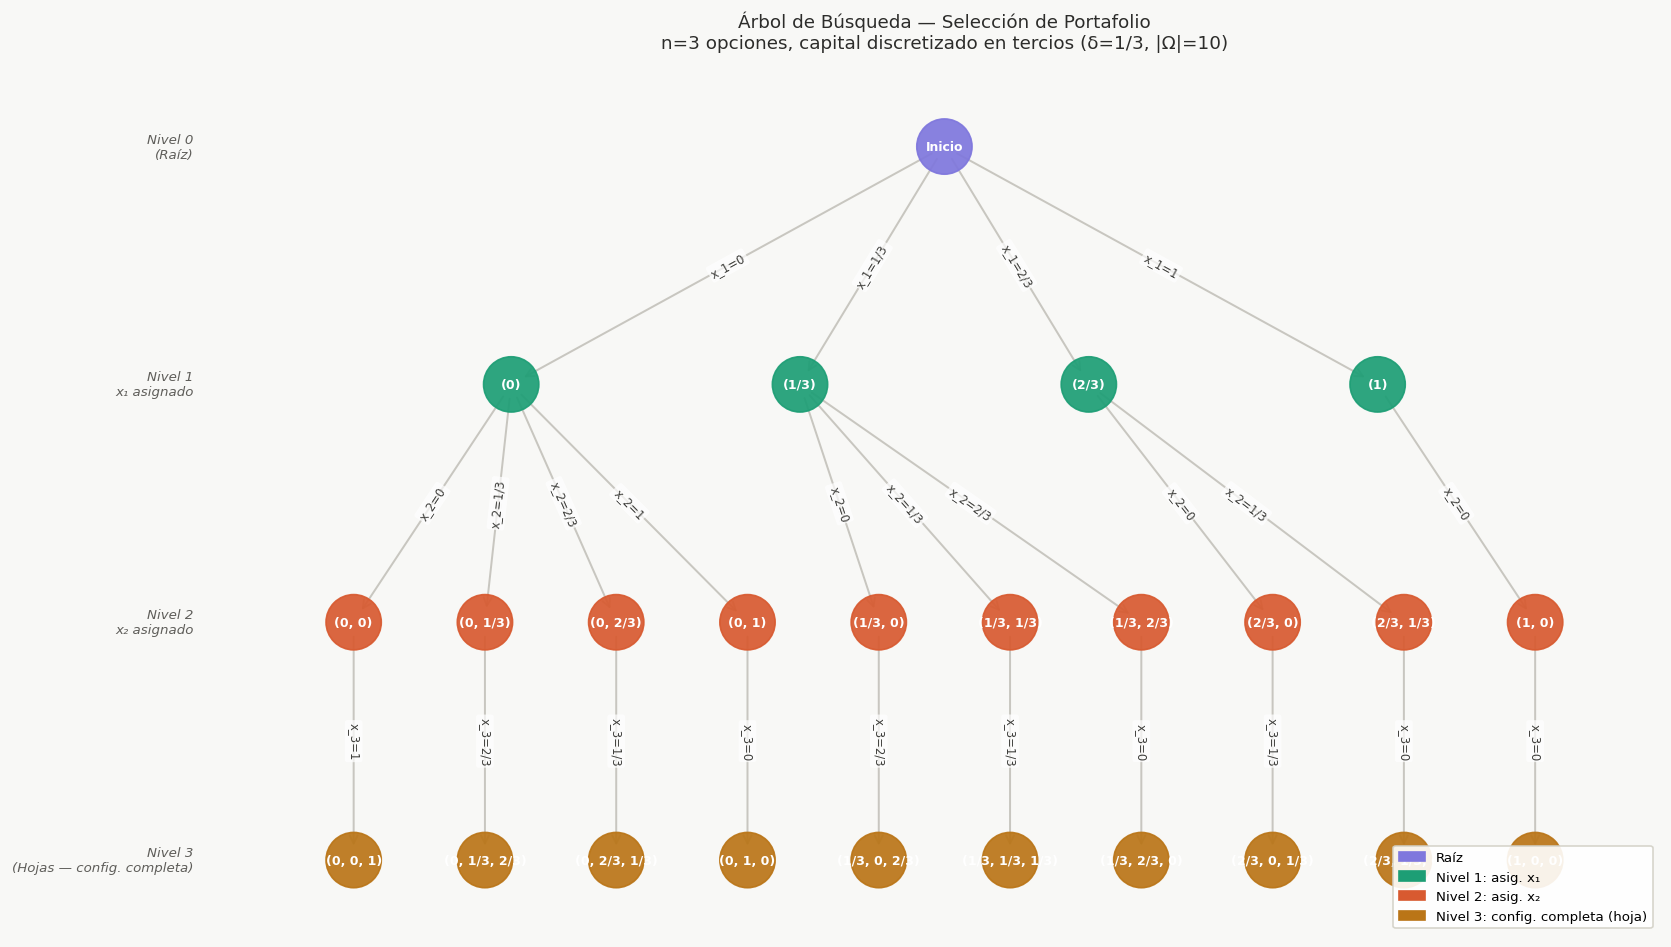

Árbol guardado como arbol_busqueda.png


In [7]:
def asignar_posiciones_arbol(G, root):
    """
    Calcula posiciones (x,y) para un árbol jerárquico.
    y = profundidad, x = orden entre hermanos.
    """
    pos = {}
    niveles = {}

    def bfs_niveles():
        from collections import deque
        cola = deque([(root, 0)])
        visitados = {root}
        while cola:
            nodo, nivel = cola.popleft()
            niveles.setdefault(nivel, []).append(nodo)
            for hijo in G.successors(nodo):
                if hijo not in visitados:
                    visitados.add(hijo)
                    cola.append((hijo, nivel + 1))

    bfs_niveles()
    for nivel, nodos in niveles.items():
        n_nodos = len(nodos)
        for i, nodo in enumerate(nodos):
            pos[nodo] = ((i + 1) / (n_nodos + 1), -nivel)
    return pos

pos = asignar_posiciones_arbol(G, root)

# Determinar profundidad de cada nodo
profundidad = nx.single_source_shortest_path_length(G, root)

# Colores por nivel
paleta = {
    0: '#7F77DD',   # púrpura  — raíz
    1: '#1D9E75',   # teal     — nivel 1
    2: '#D85A30',   # coral    — nivel 2
    3: '#BA7517',   # ámbar    — hojas
}
colores_nodo = [paleta.get(profundidad[n], '#888780') for n in G.nodes()]

# Etiquetas de nodos
def etiqueta(nodo):
    asig, restante = nodo
    if not asig:
        return 'Inicio'
    fracs = []
    for v in asig:
        num = int(round(v * 3))
        if num == 0: fracs.append('0')
        elif num == 3: fracs.append('1')
        else: fracs.append(f'{num}/3')
    return '(' + ', '.join(fracs) + ')'

labels = {n: etiqueta(n) for n in G.nodes()}

# Etiquetas de aristas
edge_labels = {}
for u, v, d in G.edges(data=True):
    p = d['peso']
    num = int(round(p * 3))
    nivel_u = len(u[0])
    opt = f'x_{nivel_u+1}='
    if num == 0: edge_labels[(u,v)] = opt + '0'
    elif num == 3: edge_labels[(u,v)] = opt + '1'
    else: edge_labels[(u,v)] = opt + f'{num}/3'

# ── Figura ──
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor('#F8F8F6')
fig.patch.set_facecolor('#F8F8F6')

nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color='#B4B2A9', arrows=True,
    arrowstyle='->', arrowsize=12,
    width=1.2, alpha=0.7,
    connectionstyle='arc3,rad=0.0'
)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=colores_nodo,
    node_size=1100, alpha=0.92
)
nx.draw_networkx_labels(
    G, pos, labels=labels, ax=ax,
    font_size=7.5, font_color='white', font_weight='bold'
)
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_size=7, font_color='#3d3d3a',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
)

# Anotaciones de nivel
for nivel, label in [(0,'Nivel 0\n(Raíz)'), (1,'Nivel 1\nx₁ asignado'),
                     (2,'Nivel 2\nx₂ asignado'), (3,'Nivel 3\n(Hojas — config. completa)')]:
    ax.text(-0.02, -nivel, label, ha='right', va='center',
            fontsize=8, color='#5F5E5A', style='italic')

# Leyenda
legend_patches = [
    mpatches.Patch(color='#7F77DD', label='Raíz'),
    mpatches.Patch(color='#1D9E75', label='Nivel 1: asig. x₁'),
    mpatches.Patch(color='#D85A30', label='Nivel 2: asig. x₂'),
    mpatches.Patch(color='#BA7517', label='Nivel 3: config. completa (hoja)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
          framealpha=0.9, edgecolor='#D3D1C7')

ax.set_title('Árbol de Búsqueda — Selección de Portafolio\n'
             'n=3 opciones, capital discretizado en tercios (δ=1/3, |Ω|=10)',
             fontsize=11, pad=14, color='#2C2C2A')
ax.axis('off')
plt.tight_layout()
plt.savefig('arbol_busqueda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Árbol guardado como arbol_busqueda.png')

## 5. Evaluación y Mejor Configuración

In [8]:
# Identificar hojas (configuraciones completas)
hojas = [n for n in G.nodes() if G.out_degree(n) == 0]

print(f'Configuraciones completas (hojas): {len(hojas)}\n')

evaluaciones = []
for hoja in hojas:
    asig, _ = hoja
    x = list(asig)
    f = rendimiento_esperado(x, r)
    var = varianza_portafolio(x, cov)
    factible = var <= sigma_max**2
    evaluaciones.append((x, f, var, factible))

evaluaciones.sort(key=lambda t: -t[1])

print(f'{"Configuración":>22} | {"f(x)":>8} | {"σ(x)":>8} | {"Factible":>9}')
print('-' * 58)
for x, f, var, fact in evaluaciones:
    cfg = '(' + ', '.join([f'{int(round(v*3))}/3' if v not in (0,1) else str(int(v)) for v in x]) + ')'
    tick = '✓' if fact else '✗'
    print(f'{cfg:>22} | {f:>8.4f} | {np.sqrt(var):>8.4f} | {tick:>9}')

mejores = [(x, f, var) for x, f, var, fact in evaluaciones if fact]
if mejores:
    x_opt, f_opt, var_opt = mejores[0]
    print(f'\n✓ Mejor configuración factible: {x_opt}')
    print(f'  Rendimiento esperado: {f_opt:.4f} ({f_opt*100:.1f}%)')
    print(f'  Desviación estándar:  {np.sqrt(var_opt):.4f} ({np.sqrt(var_opt)*100:.1f}%)')

Configuraciones completas (hojas): 10

         Configuración |     f(x) |     σ(x) |  Factible
----------------------------------------------------------
             (0, 0, 1) |   0.2000 |   0.3000 |         ✗
         (0, 1/3, 2/3) |   0.1733 |   0.2171 |         ✗
         (1/3, 0, 2/3) |   0.1500 |   0.2071 |         ✗
         (0, 2/3, 1/3) |   0.1467 |   0.1745 |         ✗
       (1/3, 1/3, 1/3) |   0.1233 |   0.1350 |         ✗
             (0, 1, 0) |   0.1200 |   0.2000 |         ✗
         (2/3, 0, 1/3) |   0.1000 |   0.1274 |         ✗
         (1/3, 2/3, 0) |   0.0967 |   0.1406 |         ✗
         (2/3, 1/3, 0) |   0.0733 |   0.0989 |         ✓
             (1, 0, 0) |   0.0500 |   0.1000 |         ✓

✓ Mejor configuración factible: [0.6666666666666666, 0.3333333333333333, 0.0]
  Rendimiento esperado: 0.0733 (7.3%)
  Desviación estándar:  0.0989 (9.9%)


## 6. Visualización de la Frontera Eficiente (continua)

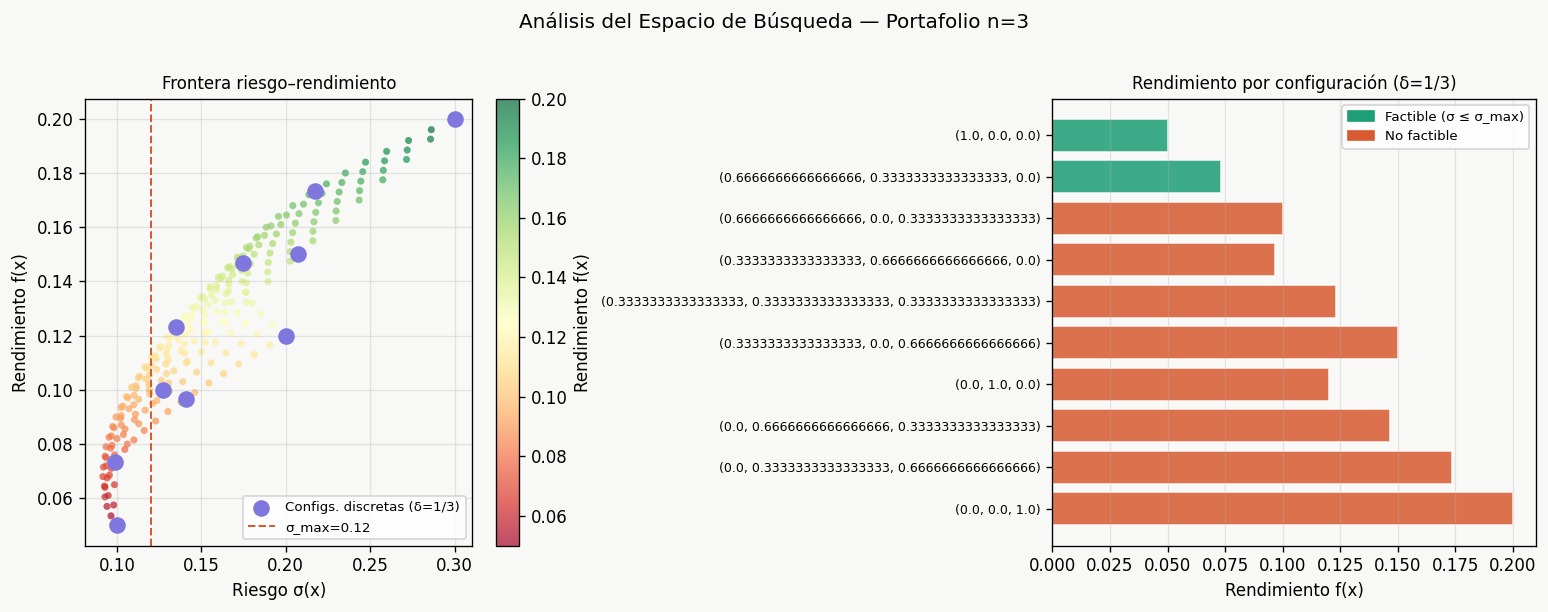

Gráfica guardada como frontera_eficiente.png


In [9]:
# Muestreo denso del símplex para n=3 (caso continuo aproximado)
configs_cont = generar_configuraciones(n=3, k=20)   # δ=0.05

rends = [rendimiento_esperado(c, r) for c in configs_cont]
riesgos = [np.sqrt(varianza_portafolio(c, cov)) for c in configs_cont]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#F8F8F6')

# ── Panel izquierdo: riesgo vs rendimiento ──
ax1 = axes[0]
ax1.set_facecolor('#F8F8F6')
sc = ax1.scatter(riesgos, rends, c=rends, cmap='RdYlGn', s=18, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax1, label='Rendimiento f(x)')

# Resaltar configuraciones discretas (k=3)
configs_disc = generar_configuraciones(n=3, k=3)
r_disc = [rendimiento_esperado(c, r) for c in configs_disc]
s_disc = [np.sqrt(varianza_portafolio(c, cov)) for c in configs_disc]
ax1.scatter(s_disc, r_disc, color='#7F77DD', s=80, zorder=5, label='Configs. discretas (δ=1/3)')

ax1.axvline(sigma_max, color='#D85A30', linestyle='--', lw=1.2, label=f'σ_max={sigma_max}')
ax1.set_xlabel('Riesgo σ(x)', fontsize=10)
ax1.set_ylabel('Rendimiento f(x)', fontsize=10)
ax1.set_title('Frontera riesgo–rendimiento', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel derecho: distribución de rendimientos (barra de todas las configs discretas) ──
ax2 = axes[1]
ax2.set_facecolor('#F8F8F6')
labels_bar = [str(c) for c in configs_disc]
colores_bar = ['#1D9E75' if fact else '#D85A30'
               for _, _, _, fact in [(c, rendimiento_esperado(c,r),
                                      varianza_portafolio(c,cov),
                                      varianza_portafolio(c,cov)<=sigma_max**2)
                                     for c in configs_disc]]
ax2.barh(range(len(r_disc)), r_disc, color=colores_bar, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(r_disc)))
ax2.set_yticklabels([str(c) for c in configs_disc], fontsize=7.5)
ax2.set_xlabel('Rendimiento f(x)', fontsize=10)
ax2.set_title('Rendimiento por configuración (δ=1/3)', fontsize=10)
ax2.axvline(0, color='gray', lw=0.5)
legend_elems = [
    mpatches.Patch(color='#1D9E75', label='Factible (σ ≤ σ_max)'),
    mpatches.Patch(color='#D85A30', label='No factible'),
]
ax2.legend(handles=legend_elems, fontsize=8)
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Análisis del Espacio de Búsqueda — Portafolio n=3', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('frontera_eficiente.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada como frontera_eficiente.png')